In [2]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 1. CARGAR LOS  NUEVOS
# ==========================================
print("⏳ Cargando los nuevos datasets...")
X_train = pd.read_csv('X_train_limpio.csv')
y_train = pd.read_csv('y_train_limpio.csv')

# ==========================================
# 2. LIMPIEZA DE DATOS (NUEVAS VARIABLES)
# ==========================================
print("🔧 Imputando nulos y transformando variables...")

# A. Rellenamos nulos numéricos (Clima y Hora) con la mediana
columnas_numericas = ['temperatura_media', 'lluvia_mm', 'velocidad_viento', 'humedad_relativa', 'hora_siniestro']
imputer = SimpleImputer(strategy='median')

# Solo aplicamos el imputer a las columnas que realmente existen en el DataFrame
columnas_existentes = [col for col in columnas_numericas if col in X_train.columns]
if columnas_existentes:
    X_train[columnas_existentes] = imputer.fit_transform(X_train[columnas_existentes])

# B. Rellenamos nulos de texto con 'DESCONOCIDO'
columnas_texto = ['participantes_siniestro', 'gravedad_siniestro']
for col in columnas_texto:
    if col in X_train.columns:
        X_train[col] = X_train[col].fillna('DESCONOCIDO')

# C. Convertimos el texto a columnas numéricas (0 y 1)
X_train_num = pd.get_dummies(X_train, columns=columnas_texto, drop_first=True)

# Pasamos los booleanos a enteros puros
columnas_bool = X_train_num.select_dtypes(include=['bool']).columns
X_train_num[columnas_bool] = X_train_num[columnas_bool].astype(int)

# ==========================================
# 3. ENTRENAMIENTO Y MÉTRICAS
# ==========================================
print("🚀 Entrenando el modelo con las nuevas clasificadoras...")

# Aislamos el target por si el CSV vino con la columna duplicada
y_train_serie = y_train.iloc[:, 0]

# Entrenamos
modelo_rf = RandomForestRegressor(random_state=42, n_estimators=100)
modelo_rf.fit(X_train_num, y_train_serie)

# Calculamos las métricas
y_pred = modelo_rf.predict(X_train_num)
r2 = r2_score(y_train_serie, y_pred)
mae = mean_absolute_error(y_train_serie, y_pred)
rmse = np.sqrt(mean_squared_error(y_train_serie, y_pred))

print("\n🎯 RESULTADOS DEL NUEVO MODELO:")
print("-" * 40)
print(f"🔹 R²: {r2:.4f}")
print(f"🔹 MAE: {mae:.4f}")
print(f"🔹 RMSE: {rmse:.4f}")
print("-" * 40)

⏳ Cargando los nuevos datasets...
🔧 Imputando nulos y transformando variables...
🚀 Entrenando el modelo con las nuevas clasificadoras...

🎯 RESULTADOS DEL NUEVO MODELO:
----------------------------------------
🔹 R²: 0.8452
🔹 MAE: 0.0988
🔹 RMSE: 0.2224
----------------------------------------


/tmp/ipykernel_15619/1834320004.py:42: UserWarning: Glyph 128064 (\N{EYES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15619/1834320004.py:42: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128064 (\N{EYES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


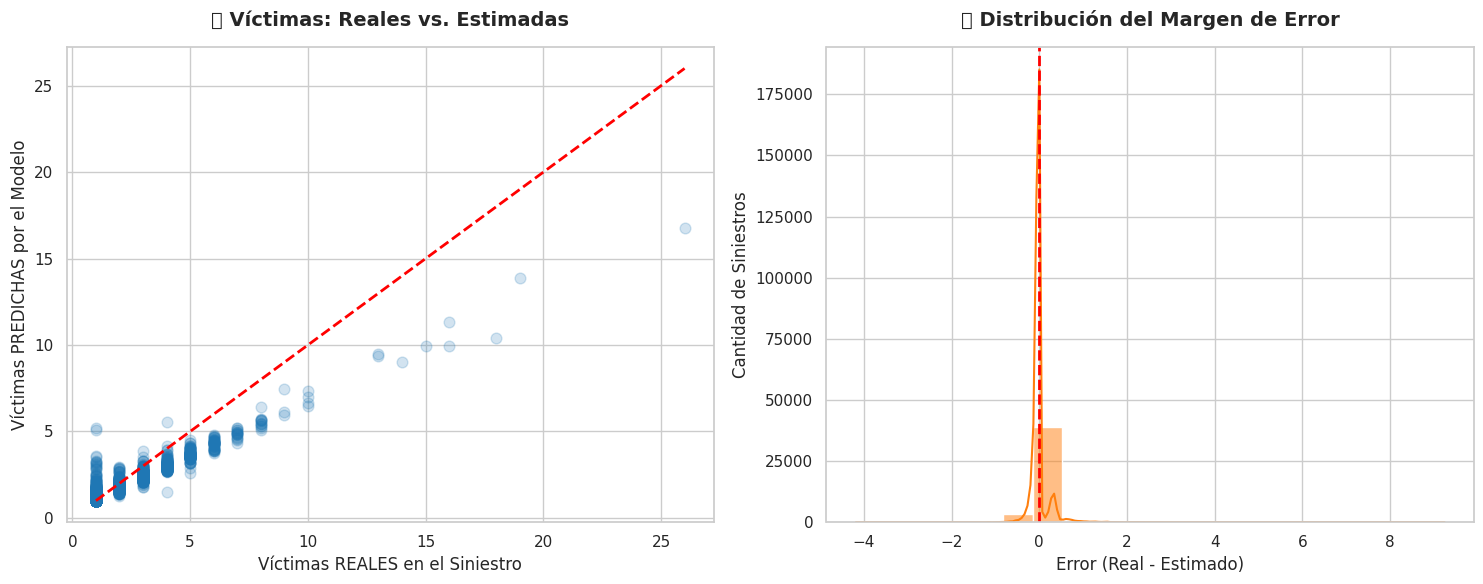

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo para que se vea limpio y profesional
sns.set_theme(style="whitegrid")

# Calculamos los residuos (El error: Valor Real - Valor Predicho)
residuos = y_train_serie - y_pred

# Creamos un "lienzo" con dos gráficos uno al lado del otro
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ==========================================
# 📊 GRÁFICO 1: Real vs. Estimado (Scatter Plot)
# ==========================================
# Usamos alpha=0.2 (transparencia) porque como los accidentes tienen números enteros (1, 2, 3...),
# los puntos se superponen. Así vemos dónde está la mayor "mancha" de datos.
axes[0].scatter(y_train_serie, y_pred, alpha=0.2, color='#1f77b4', s=60)

# Dibujamos la línea de la perfección (diagonal roja)
min_val = min(y_train_serie.min(), y_pred.min())
max_val = max(y_train_serie.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

axes[0].set_title('👀 Víctimas: Reales vs. Estimadas', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Víctimas REALES en el Siniestro', fontsize=12)
axes[0].set_ylabel('Víctimas PREDICHAS por el Modelo', fontsize=12)

# ==========================================
# 🎯 GRÁFICO 2: Distribución del Error (Residuos)
# ==========================================
sns.histplot(residuos, bins=20, kde=True, ax=axes[1], color='#ff7f0e')

# Línea vertical en el cero (donde el modelo no tiene error)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)

axes[1].set_title('🎯 Distribución del Margen de Error', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Error (Real - Estimado)', fontsize=12)
axes[1].set_ylabel('Cantidad de Siniestros', fontsize=12)

# Mostramos el dashboard final
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import numpy as np

# 1. Armamos el DataFrame completo cruzando la realidad vs la predicción
df_grilla = pd.DataFrame({
    'Víctimas REALES': y_train_serie.values,
    'Predicción del MODELO': np.round(y_pred, 2),
    'Diferencia (Error)': np.round(abs(y_train_serie.values - y_pred), 2)
})

# 2. APLICAMOS EL FILTRO: Nos quedamos SOLO con los casos de 2 o más víctimas
df_casos_graves = df_grilla[df_grilla['Víctimas REALES'] > 1]

print(f"🔍 Encontramos {len(df_casos_graves)} siniestros en entrenamiento con más de 1 víctima.")
print("-" * 50)

# 3. Mostramos 15 casos al azar de este grupo específico
df_casos_graves.sample(15, random_state=88)

🔍 Encontramos 4561 siniestros en entrenamiento con más de 1 víctima.
--------------------------------------------------


,Víctimas REALES,Predicción del MODELO,Diferencia (Error)
21384,2,1.71,0.29
42667,2,1.66,0.34
14948,2,1.71,0.29
24158,2,1.63,0.37
38065,4,3.36,0.64
24765,2,1.74,0.26
18082,3,2.35,0.65
39623,2,1.75,0.25
28387,3,1.99,1.01
21927,4,3.23,0.77


🏆 TOP 10 VARIABLES CON MÁS PESO EN EL MODELO:
--------------------------------------------------
                                           Variable  Peso (%)
                                   velocidad_viento 21.376855
                                  temperatura_media 19.620440
                                   humedad_relativa 14.601305
                                      rango_horario 11.351569
                                                mes  8.210105
                                   anio_siniestro_x  4.755333
                            gravedad_siniestro_LEVE  1.942201
                      participantes_siniestro_SD-SD  1.248560
                                          lluvia_mm  1.165125
participantes_siniestro_TRANSPORTE PUBLICO-MULTIPLE  1.039619


/tmp/ipykernel_15619/2761559555.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso (%)', y='Variable', data=df_importancias.head(15), palette='magma')
/tmp/ipykernel_15619/2761559555.py:36: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


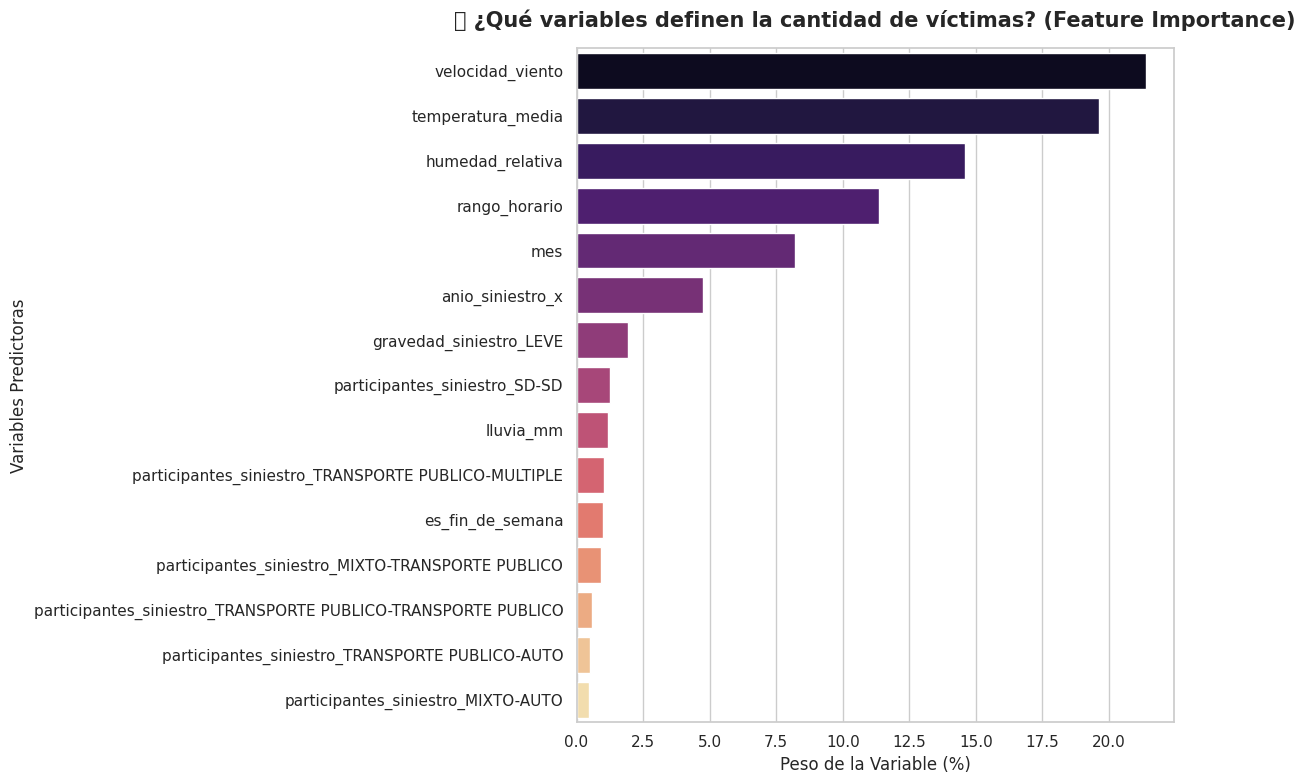

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# ⚖️ CALCULAR EL PESO DE LAS VARIABLES
# ==========================================
# 1. Extraemos las importancias directas del modelo entrenado
importancias = modelo_rf.feature_importances_
columnas = X_train_num.columns

# 2. Armamos un DataFrame y pasamos el peso a porcentaje
df_importancias = pd.DataFrame({
    'Variable': columnas,
    'Peso (%)': importancias * 100
})

# 3. Ordenamos de mayor a menor importancia
df_importancias = df_importancias.sort_values(by='Peso (%)', ascending=False)

# Mostramos el Top 10 en texto rápido
print("🏆 TOP 10 VARIABLES CON MÁS PESO EN EL MODELO:")
print("-" * 50)
print(df_importancias.head(10).to_string(index=False))

# ==========================================
# 📊 GRAFICAR LA DISTRIBUCIÓN DEL PESO
# ==========================================
plt.figure(figsize=(12, 8))
# Graficamos el Top 15 para no saturar si hay muchas columnas de dummies
sns.barplot(x='Peso (%)', y='Variable', data=df_importancias.head(15), palette='magma')

plt.title('🔍 ¿Qué variables definen la cantidad de víctimas? (Feature Importance)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Peso de la Variable (%)', fontsize=12)
plt.ylabel('Variables Predictoras', fontsize=12)
plt.tight_layout()
plt.show()